# 01 — Data Exploration & Scoping

**Retail Demand Forecasting & Inventory Optimization**

This notebook explores the raw Favorita grocery sales data (Corporación
Favorita, via Kaggle) and documents the scoping decisions behind the
processed dataset used in the rest of this project.

Raw data: 125,497,040 rows — 54 stores, 4,100 items (33 product
families), daily, 2013-01-01 to 2017-08-15.

## Why scope down from the full dataset?

At the individual store-item level, most series are mostly zeros — a
given item just doesn't sell every day at every store. That's a
different, harder problem (intermittent demand) than what I'm
demonstrating here.

So I aggregated to daily unit sales per store x product family, for the
top 10 stores and top 8 categories by volume (see `src/data_prep.py`).
Still keeps real variation between stores and categories, but the series
are dense enough to actually forecast and compare fairly.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/daily_sales_by_store_family.csv", parse_dates=["date"])
print(df.shape)
df.head()

(133096, 11)


,date,store_nbr,family,unit_sales,n_items_on_promo,city,state,type,cluster,oil_price,is_holiday
0,2013-01-02,3,BEVERAGES,4486.0,0,Quito,Pichincha,D,8,93.14,False
1,2013-01-03,3,BEVERAGES,3367.0,0,Quito,Pichincha,D,8,92.97,False
2,2013-01-04,3,BEVERAGES,3283.0,0,Quito,Pichincha,D,8,93.12,False
3,2013-01-05,3,BEVERAGES,4886.0,0,Quito,Pichincha,D,8,93.12,False
4,2013-01-06,3,BEVERAGES,5474.0,0,Quito,Pichincha,D,8,93.12,False


In [2]:
print("Date range:", df['date'].min().date(), "to", df['date'].max().date())
print("Stores:", sorted(df['store_nbr'].unique()))
print("Families:", sorted(df['family'].unique()))
print()
df.describe(include='all').T

Date range: 2013-01-02 to 2017-08-15
Stores: [np.int64(3), np.int64(8), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51)]
Families: ['BEVERAGES', 'BREAD/BAKERY', 'CLEANING', 'DAIRY', 'GROCERY I', 'MEATS', 'POULTRY', 'PRODUCE']



,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,133096,NaN,NaN,NaN,2015-04-30 15:24:37.477910784,2013-01-02 00:00:00,2014-03-08 00:00:00,2015-05-02 00:00:00,2016-06-24 00:00:00,2017-08-15 00:00:00,NaN
store_nbr,133096.0,NaN,NaN,NaN,39.132859,3.0,44.0,47.0,49.0,51.0,16.939044
family,133096,8,BEVERAGES,16790,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unit_sales,133096.0,NaN,NaN,NaN,2874.186215,1.0,846.897775,1562.0,3885.0,76090.0,3137.193403
n_items_on_promo,133096.0,NaN,NaN,NaN,10.774163,0.0,0.0,1.0,7.0,252.0,27.141147
city,133096,3,Quito,106448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,133096,3,Pichincha,106448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,133096,2,A,106595,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cluster,133096.0,NaN,NaN,NaN,11.601416,5.0,8.0,14.0,14.0,17.0,3.499864
oil_price,133096.0,NaN,NaN,NaN,67.707999,26.19,46.3,53.26,95.72,110.62,25.653407


## Overall daily demand trend

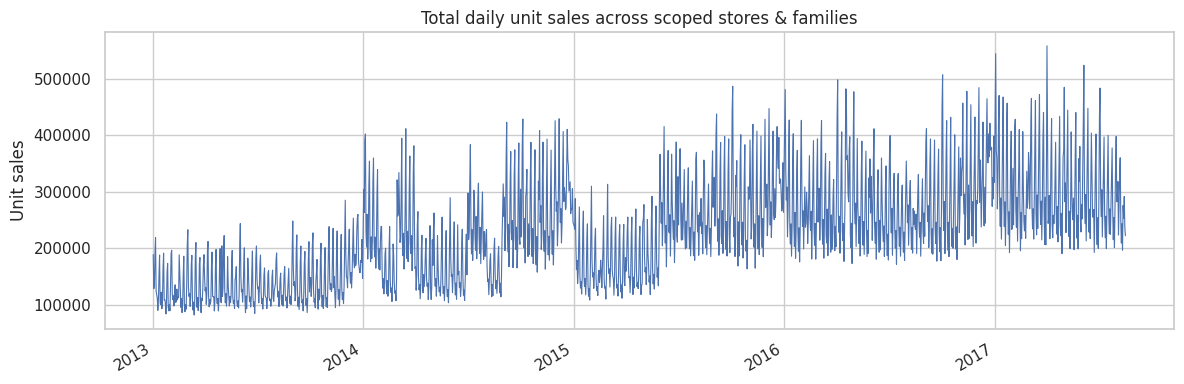

In [3]:
daily_total = df.groupby("date")["unit_sales"].sum()

fig, ax = plt.subplots(figsize=(12, 4))
daily_total.plot(ax=ax, linewidth=0.8)
ax.set_title("Total daily unit sales across scoped stores & families")
ax.set_ylabel("Unit sales")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

Clear yearly seasonality and a holiday spike, especially around year-end.
A flat average would miss this completely.

## Day-of-week seasonality

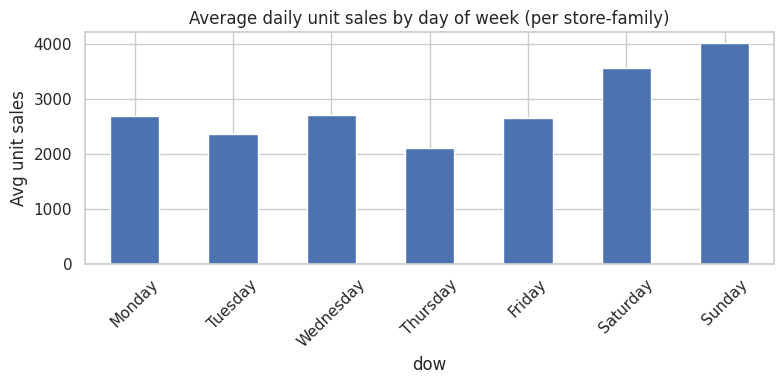

In [4]:
df["dow"] = df["date"].dt.day_name()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_avg = df.groupby("dow")["unit_sales"].mean().reindex(order)

fig, ax = plt.subplots(figsize=(8, 4))
dow_avg.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Average daily unit sales by day of week (per store-family)")
ax.set_ylabel("Avg unit sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Sales by store

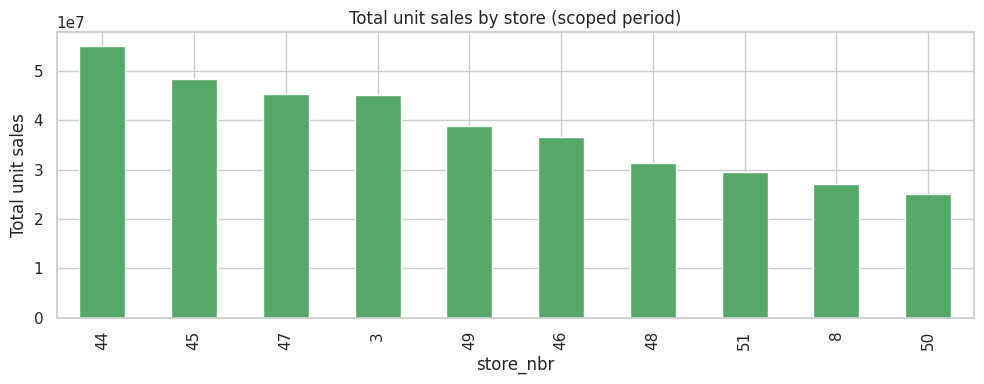

In [5]:
store_total = df.groupby("store_nbr")["unit_sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
store_total.plot(kind="bar", ax=ax, color="#55A868")
ax.set_title("Total unit sales by store (scoped period)")
ax.set_ylabel("Total unit sales")
ax.set_xlabel("store_nbr")
plt.tight_layout()
plt.show()

## Sales by product family

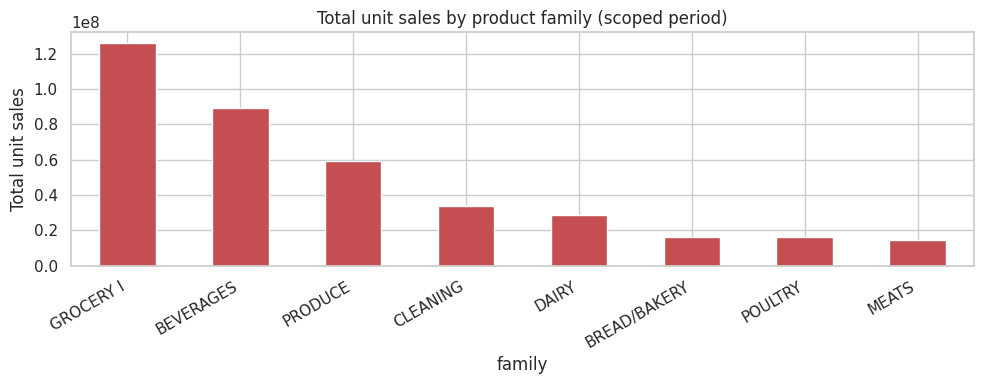

In [6]:
family_total = df.groupby("family")["unit_sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
family_total.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_title("Total unit sales by product family (scoped period)")
ax.set_ylabel("Total unit sales")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Do promotions and holidays actually move sales?

In [7]:
promo_effect = (
    df.assign(on_promo=df["n_items_on_promo"] > 0)
      .groupby("on_promo")["unit_sales"].mean()
)
holiday_effect = df.groupby("is_holiday")["unit_sales"].mean()

print("Avg daily sales, no items on promo vs at least one item on promo:")
print(promo_effect)
print()
print("Avg daily sales, non-holiday vs holiday:")
print(holiday_effect)

Avg daily sales, no items on promo vs at least one item on promo:
on_promo
False    1901.507477
True     3795.438417
Name: unit_sales, dtype: float64

Avg daily sales, non-holiday vs holiday:
is_holiday
False    2822.847588
True     3187.836955
Name: unit_sales, dtype: float64


Both promotions and holidays move the average, so the models in the next
notebook use them as features rather than relying on date/seasonality
alone.

## Next: `02_forecasting_models.ipynb`

Builds and backtests the three forecasting approaches (naive/seasonal
baseline, SARIMA/Prophet, XGBoost/LightGBM) on this panel, scored with
MAPE, WMAPE, and bias via rolling-origin backtesting.